In [6]:
import tensorflow as tf
from keras.utils import to_categorical
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
from keras.optimizers import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import os
from keras.utils import load_img, img_to_array
from tqdm import tqdm
import cv2

In [7]:
train_dr = '/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train' 
test_dr = '/kaggle/input/datasets/odins0n/ucf-crime-dataset/Test'

print(f"Training Data Directory: {train_dr}")
print(f"Testing Data Directory: {test_dr}")
print(f"\nChecking if directories exist:")
print(f"Train directory exists: {os.path.exists(train_dr)}")
print(f"Test directory exists: {os.path.exists(test_dr)}")

if os.path.exists(train_dr):
    print(f"\nClasses in Train directory: {len(os.listdir(train_dr))}")
    print(f"Class names: {sorted(os.listdir(train_dr))}")

Training Data Directory: /kaggle/input/datasets/odins0n/ucf-crime-dataset/Train
Testing Data Directory: /kaggle/input/datasets/odins0n/ucf-crime-dataset/Test

Checking if directories exist:
Train directory exists: True
Test directory exists: True

Classes in Train directory: 14
Class names: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [8]:
def createdataframe(dir):
    image_path = []
    labels = []
    for label in os.listdir(dir):
        for image in os.listdir(os.path.join(dir, label)):
            image_path.append(os.path.join(dir, label, image))
            labels.append(label)
        print(label, "Completed")
    return image_path, labels

train = pd.DataFrame()
train['image'], train['labels'] = createdataframe(train_dr)

print(f"\nTrain DataFrame Shape: {train.shape}")
print(f"Total Training Images: {len(train)}")
print(f"\nFirst few rows:")
print(train.head())

RoadAccidents Completed
Assault Completed
Vandalism Completed
Arrest Completed
Shooting Completed
NormalVideos Completed
Arson Completed
Explosion Completed
Shoplifting Completed
Robbery Completed
Stealing Completed
Burglary Completed
Abuse Completed
Fighting Completed

Train DataFrame Shape: (1266345, 2)
Total Training Images: 1266345

First few rows:
                                               image         labels
0  /kaggle/input/datasets/odins0n/ucf-crime-datas...  RoadAccidents
1  /kaggle/input/datasets/odins0n/ucf-crime-datas...  RoadAccidents
2  /kaggle/input/datasets/odins0n/ucf-crime-datas...  RoadAccidents
3  /kaggle/input/datasets/odins0n/ucf-crime-datas...  RoadAccidents
4  /kaggle/input/datasets/odins0n/ucf-crime-datas...  RoadAccidents


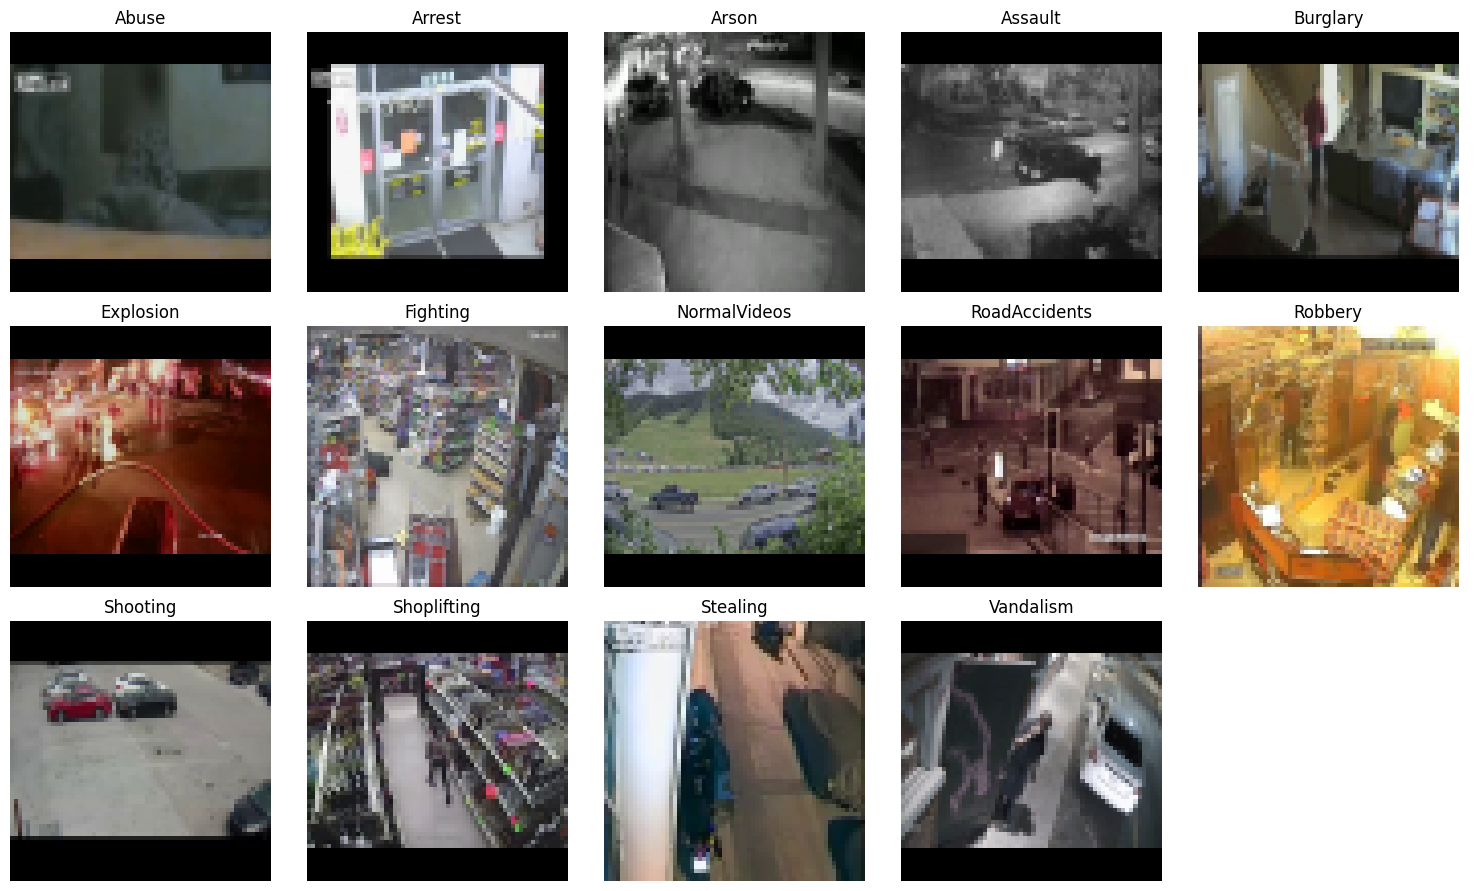

In [4]:
def show_class_images(train_df, num_images_per_class=1):
    classes = sorted(train_df['labels'].unique())
    num_columns = min(len(classes), 5)
    num_rows = (len(classes) + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 3, num_rows * 3))
    axes = axes.flatten()
    
    for i, class_name in enumerate(classes):
        img_path = train_df[train_df['labels'] == class_name]['image'].iloc[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(class_name)
        axes[i].axis('off')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

show_class_images(train)

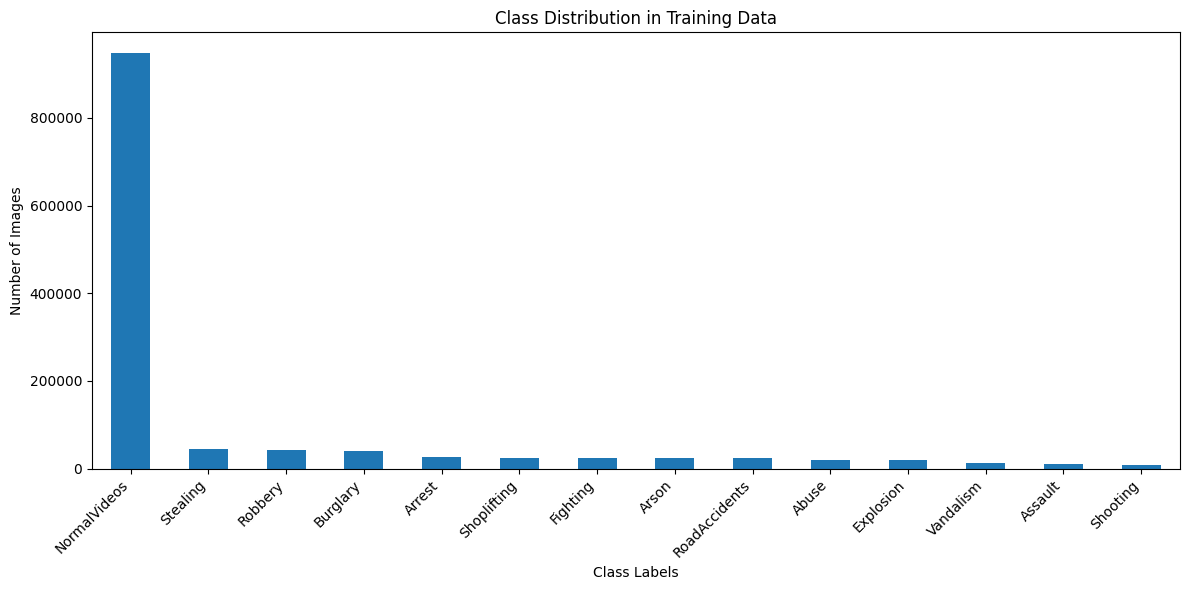


Class Distribution:
labels
NormalVideos     947768
Stealing          44802
Robbery           41493
Burglary          39504
Arrest            26397
Shoplifting       24835
Fighting          24684
Arson             24421
RoadAccidents     23486
Abuse             19076
Explosion         18753
Vandalism         13626
Assault           10360
Shooting           7140
Name: count, dtype: int64


In [5]:
train['labels'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(train['labels'].value_counts())

RoadAccidents Completed
Assault Completed
Vandalism Completed
Arrest Completed
Shooting Completed
NormalVideos Completed
Arson Completed
Explosion Completed
Shoplifting Completed
Robbery Completed
Stealing Completed
Burglary Completed
Abuse Completed
Fighting Completed

Test DataFrame Shape: (111308, 2)
Total Testing Images: 111308


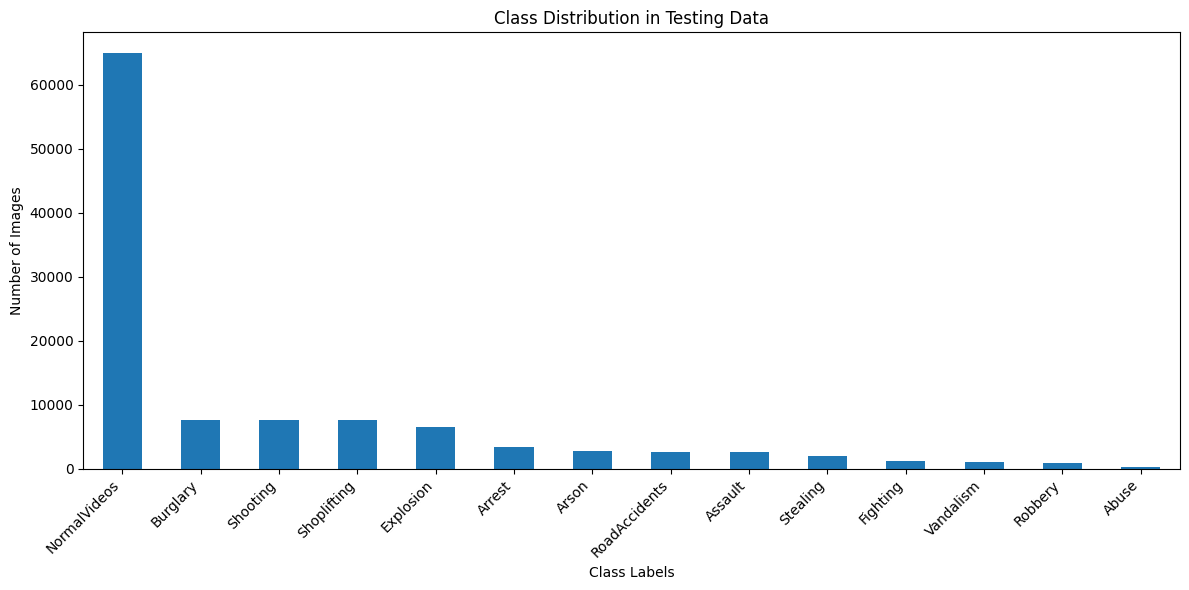


Class Distribution:
labels
NormalVideos     64952
Burglary          7657
Shooting          7630
Shoplifting       7623
Explosion         6510
Arrest            3365
Arson             2793
RoadAccidents     2663
Assault           2657
Stealing          1984
Fighting          1231
Vandalism         1111
Robbery            835
Abuse              297
Name: count, dtype: int64


In [6]:
test = pd.DataFrame()
test['image'], test['labels'] = createdataframe(test_dr)

print(f"\nTest DataFrame Shape: {test.shape}")
print(f"Total Testing Images: {len(test)}")

test['labels'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution in Testing Data')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClass Distribution:")
print(test['labels'].value_counts())

In [7]:
def remove_labels(df):
    labels_to_remove = ['Robbery', 'Vandalism', 'RoadAccidents', 'Arson', 'Arrest']
    df_filtered = df[~df['labels'].isin(labels_to_remove)]
    return df_filtered

train = remove_labels(train)
test = remove_labels(test)

print("After removing classes:")
print(f"\nTrain DataFrame Shape: {train.shape}")
print("Train Class Distribution:")
print(train['labels'].value_counts())

print(f"\nTest DataFrame Shape: {test.shape}")
print("\nTest Class Distribution:")
print(test['labels'].value_counts())

After removing classes:

Train DataFrame Shape: (1136922, 2)
Train Class Distribution:
labels
NormalVideos    947768
Stealing         44802
Burglary         39504
Shoplifting      24835
Fighting         24684
Abuse            19076
Explosion        18753
Assault          10360
Shooting          7140
Name: count, dtype: int64

Test DataFrame Shape: (100541, 2)

Test Class Distribution:
labels
NormalVideos    64952
Burglary         7657
Shooting         7630
Shoplifting      7623
Explosion        6510
Assault          2657
Stealing         1984
Fighting         1231
Abuse             297
Name: count, dtype: int64


Balanced Train Class Distribution:
labels
NormalVideos    50000
Stealing        44802
Burglary        39504
Shoplifting     24835
Fighting        24684
Abuse           19076
Explosion       18753
Assault         10360
Shooting         7140
Name: count, dtype: int64

Total Images after balancing: 239154


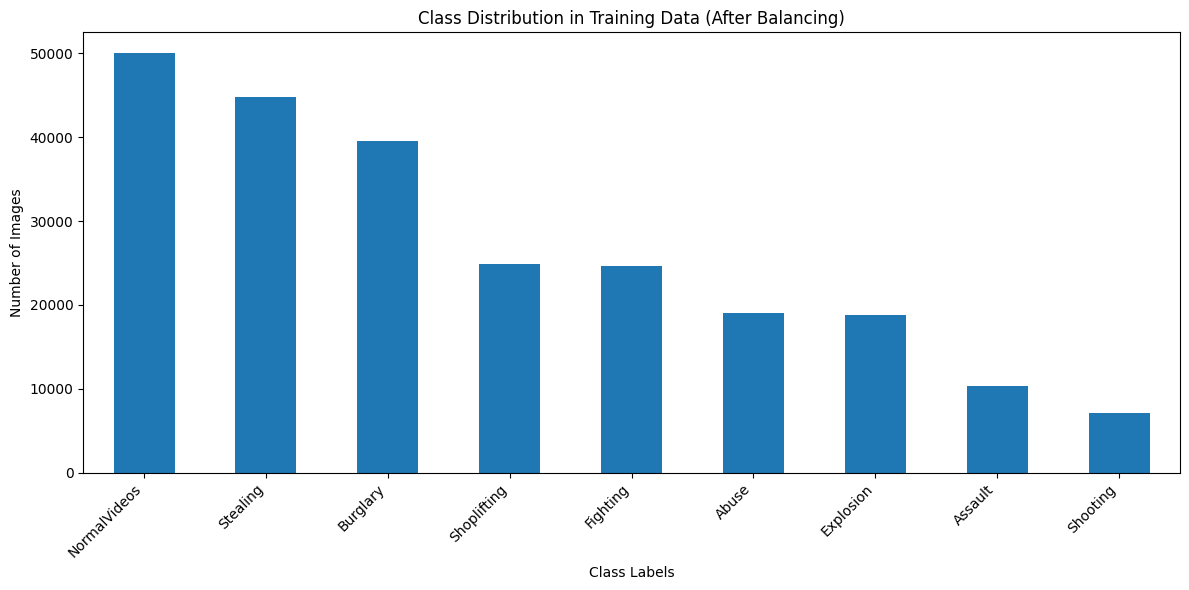

In [8]:
train_normal_count = 50000

train_majority = train[train['labels'] == 'NormalVideos']
train_minority = train[train['labels'] != 'NormalVideos']

train_majority_downsampled = train_majority.sample(n=train_normal_count, random_state=42)

train_balanced = pd.concat([train_majority_downsampled, train_minority])

train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced Train Class Distribution:")
print(train_balanced['labels'].value_counts())
print(f"\nTotal Images after balancing: {len(train_balanced)}")

train_balanced['labels'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution in Training Data (After Balancing)')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

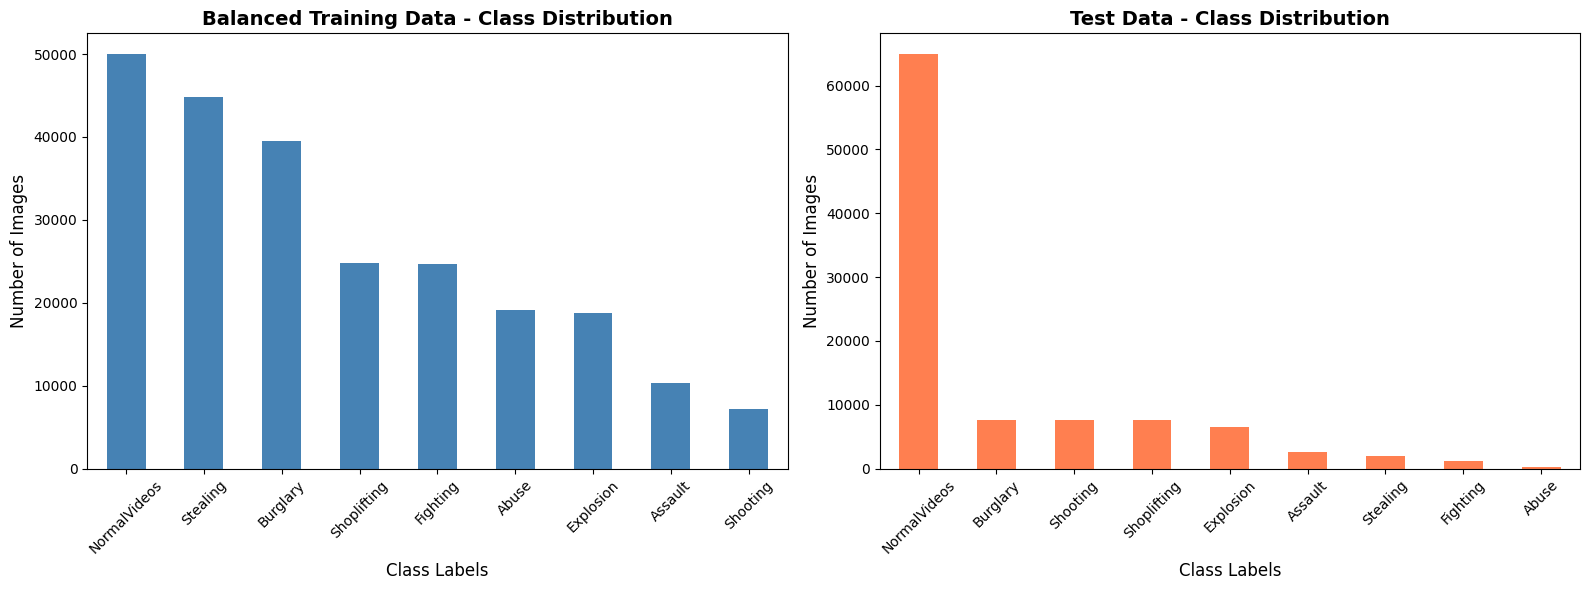

Training Data Summary:
Total Images: 239154
Number of Classes: 9

Test Data Summary:
Total Images: 100541
Number of Classes: 9


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_balanced['labels'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Balanced Training Data - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class Labels', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

test['labels'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Data - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class Labels', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Training Data Summary:")
print(f"Total Images: {len(train_balanced)}")
print(f"Number of Classes: {train_balanced['labels'].nunique()}")
print(f"\nTest Data Summary:")
print(f"Total Images: {len(test)}")
print(f"Number of Classes: {test['labels'].nunique()}")

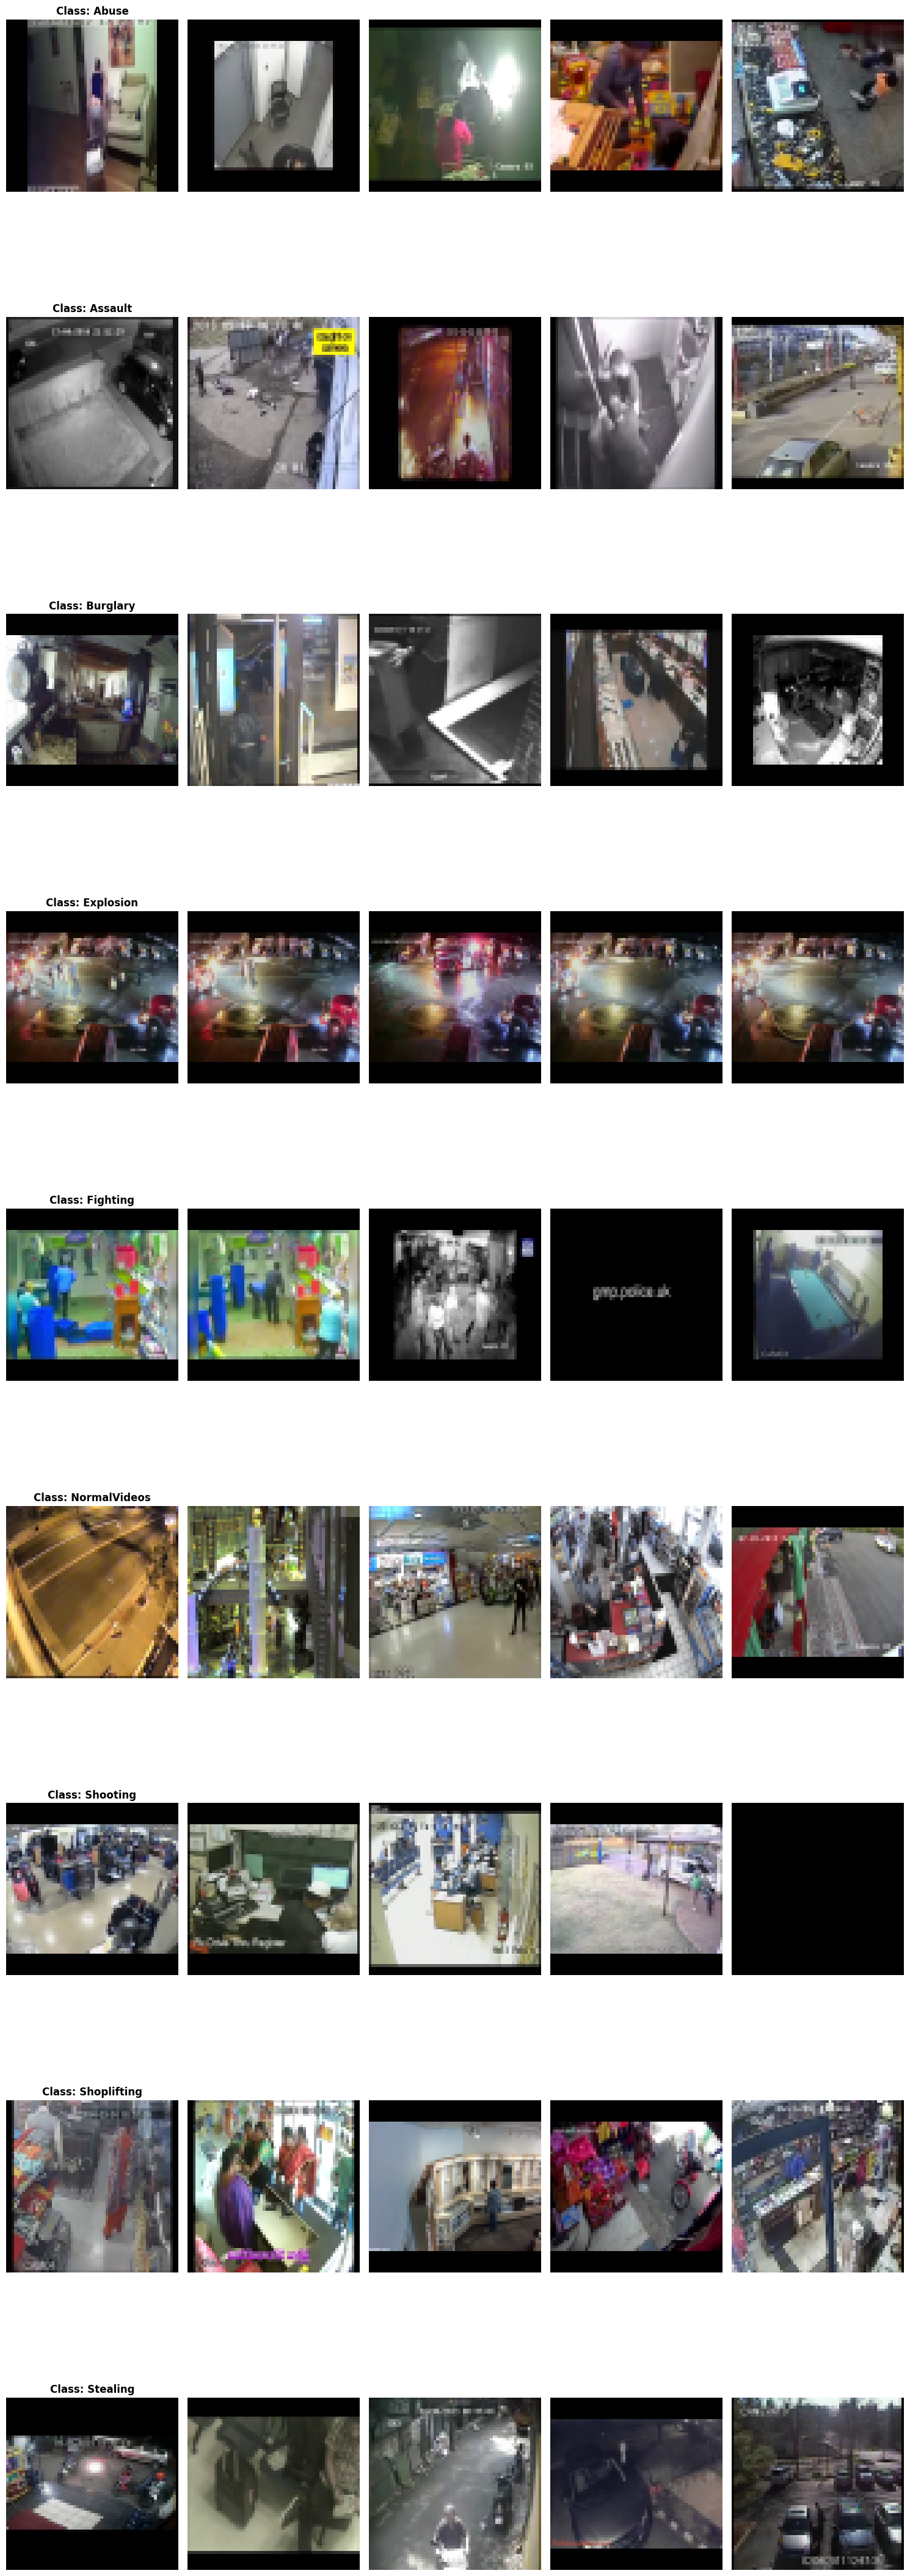

In [10]:
unique_classes = np.unique(train_balanced['labels'])
fig, axes = plt.subplots(len(unique_classes), 5, figsize=(15, 5 * len(unique_classes)))
axes = axes.flatten()

for idx, class_label in enumerate(unique_classes):
    class_images = train_balanced[train_balanced['labels'] == class_label].iloc[:5]
    for i, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['image']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx * 5 + i].imshow(img)
        axes[idx * 5 + i].axis('off')
        if i == 0:
            axes[idx * 5].set_title(f'Class: {class_label}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Image Dimension Analysis (Sample of 100 images):

Unique dimensions found:
Height  Width  Channels
64      64     3           100
Name: count, dtype: int64

Most common image size:
Height: 64
Width: 64
Channels: 3


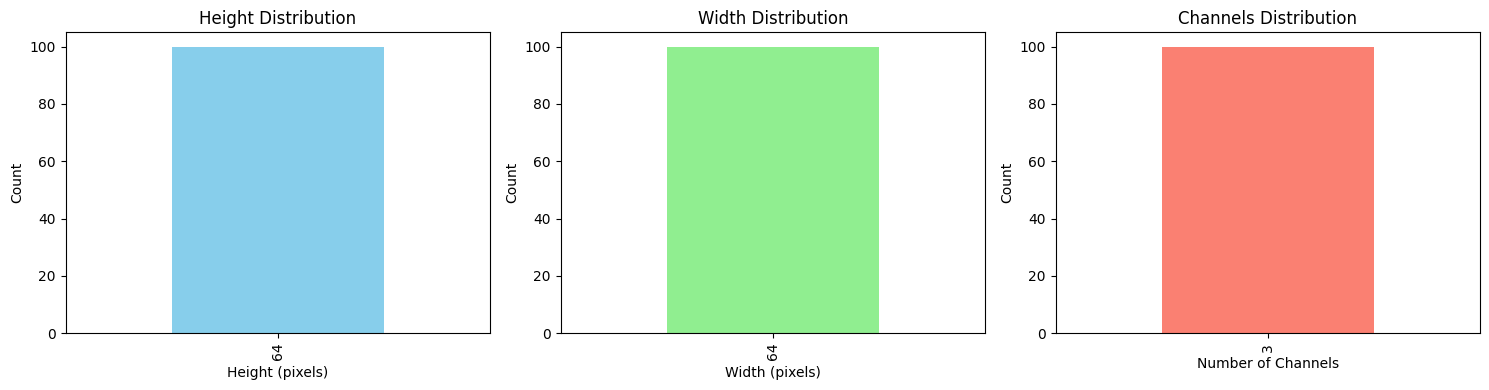

In [11]:
sample_images = train_balanced.sample(n=100, random_state=42)
image_sizes = []

for img_path in sample_images['image']:
    img = cv2.imread(img_path)
    if img is not None:
        image_sizes.append(img.shape)

image_sizes_df = pd.DataFrame(image_sizes, columns=['Height', 'Width', 'Channels'])

print("Image Dimension Analysis (Sample of 100 images):")
print(f"\nUnique dimensions found:")
print(image_sizes_df.value_counts())

print(f"\nMost common image size:")
print(f"Height: {image_sizes_df['Height'].mode()[0]}")
print(f"Width: {image_sizes_df['Width'].mode()[0]}")
print(f"Channels: {image_sizes_df['Channels'].mode()[0]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
image_sizes_df['Height'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Height Distribution')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Count')

image_sizes_df['Width'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Width Distribution')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_ylabel('Count')

image_sizes_df['Channels'].value_counts().plot(kind='bar', ax=axes[2], color='salmon')
axes[2].set_title('Channels Distribution')
axes[2].set_xlabel('Number of Channels')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

Assault: 10000 images
Shooting: 7140 images
NormalVideos: 10000 images
Explosion: 10000 images
Shoplifting: 10000 images
Stealing: 10000 images
Burglary: 10000 images
Abuse: 10000 images
Fighting: 10000 images

Total Images after balancing: 87140

Balanced Train Class Distribution:
labels
Abuse           10000
Assault         10000
Burglary        10000
Explosion       10000
Fighting        10000
NormalVideos    10000
Shooting         7140
Shoplifting     10000
Stealing        10000
Name: count, dtype: int64


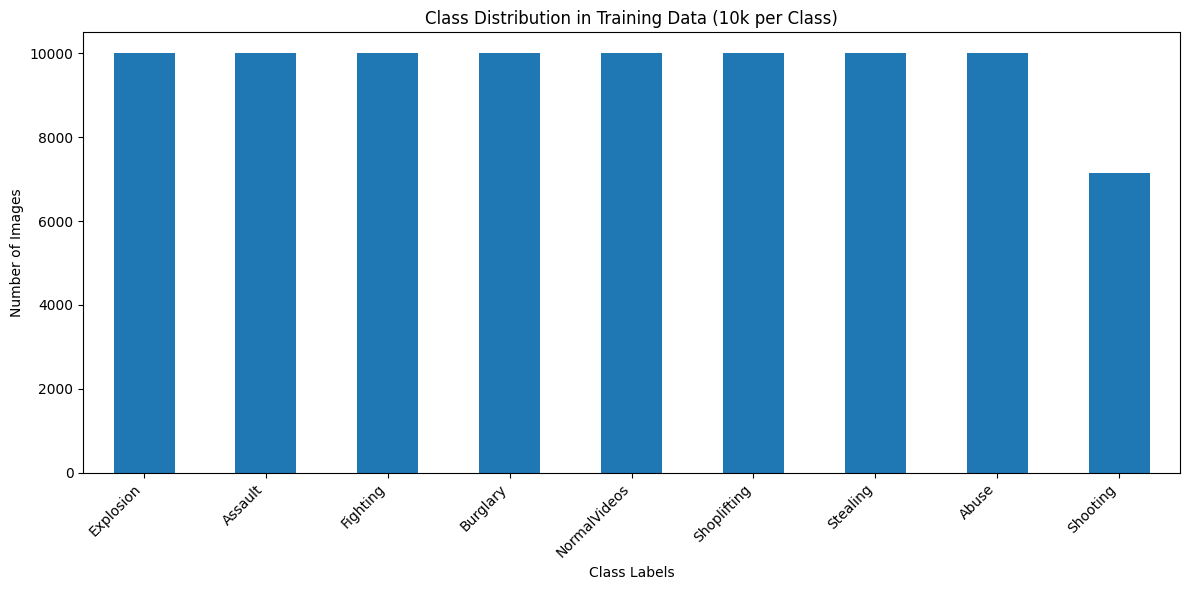

In [12]:
samples_per_class = 10000

balanced_dfs = []
for label in train['labels'].unique():
    class_df = train[train['labels'] == label]
    if len(class_df) >= samples_per_class:
        sampled_df = class_df.sample(n=samples_per_class, random_state=42)
    else:
        sampled_df = class_df
    balanced_dfs.append(sampled_df)
    print(f"{label}: {len(sampled_df)} images")

train_balanced = pd.concat(balanced_dfs)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal Images after balancing: {len(train_balanced)}")
print("\nBalanced Train Class Distribution:")
print(train_balanced['labels'].value_counts().sort_index())

train_balanced['labels'].value_counts().plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution in Training Data (10k per Class)')
plt.xlabel('Class Labels')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

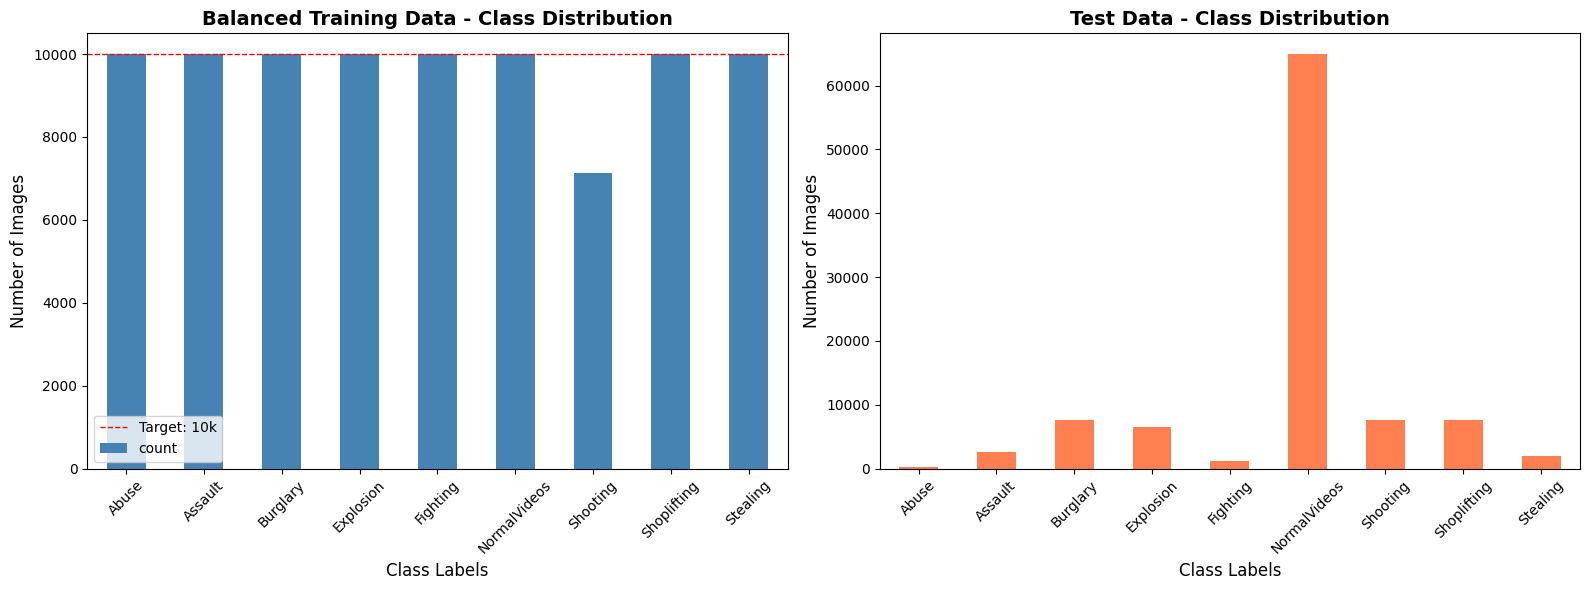

Training Data Summary:
Total Images: 87140
Number of Classes: 9

Test Data Summary:
Total Images: 100541
Number of Classes: 9


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_balanced['labels'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Balanced Training Data - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class Labels', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=10000, color='red', linestyle='--', linewidth=1, label='Target: 10k')
axes[0].legend()

test['labels'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Test Data - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class Labels', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Training Data Summary:")
print(f"Total Images: {len(train_balanced)}")
print(f"Number of Classes: {train_balanced['labels'].nunique()}")
print(f"\nTest Data Summary:")
print(f"Total Images: {len(test)}")
print(f"Number of Classes: {test['labels'].nunique()}")

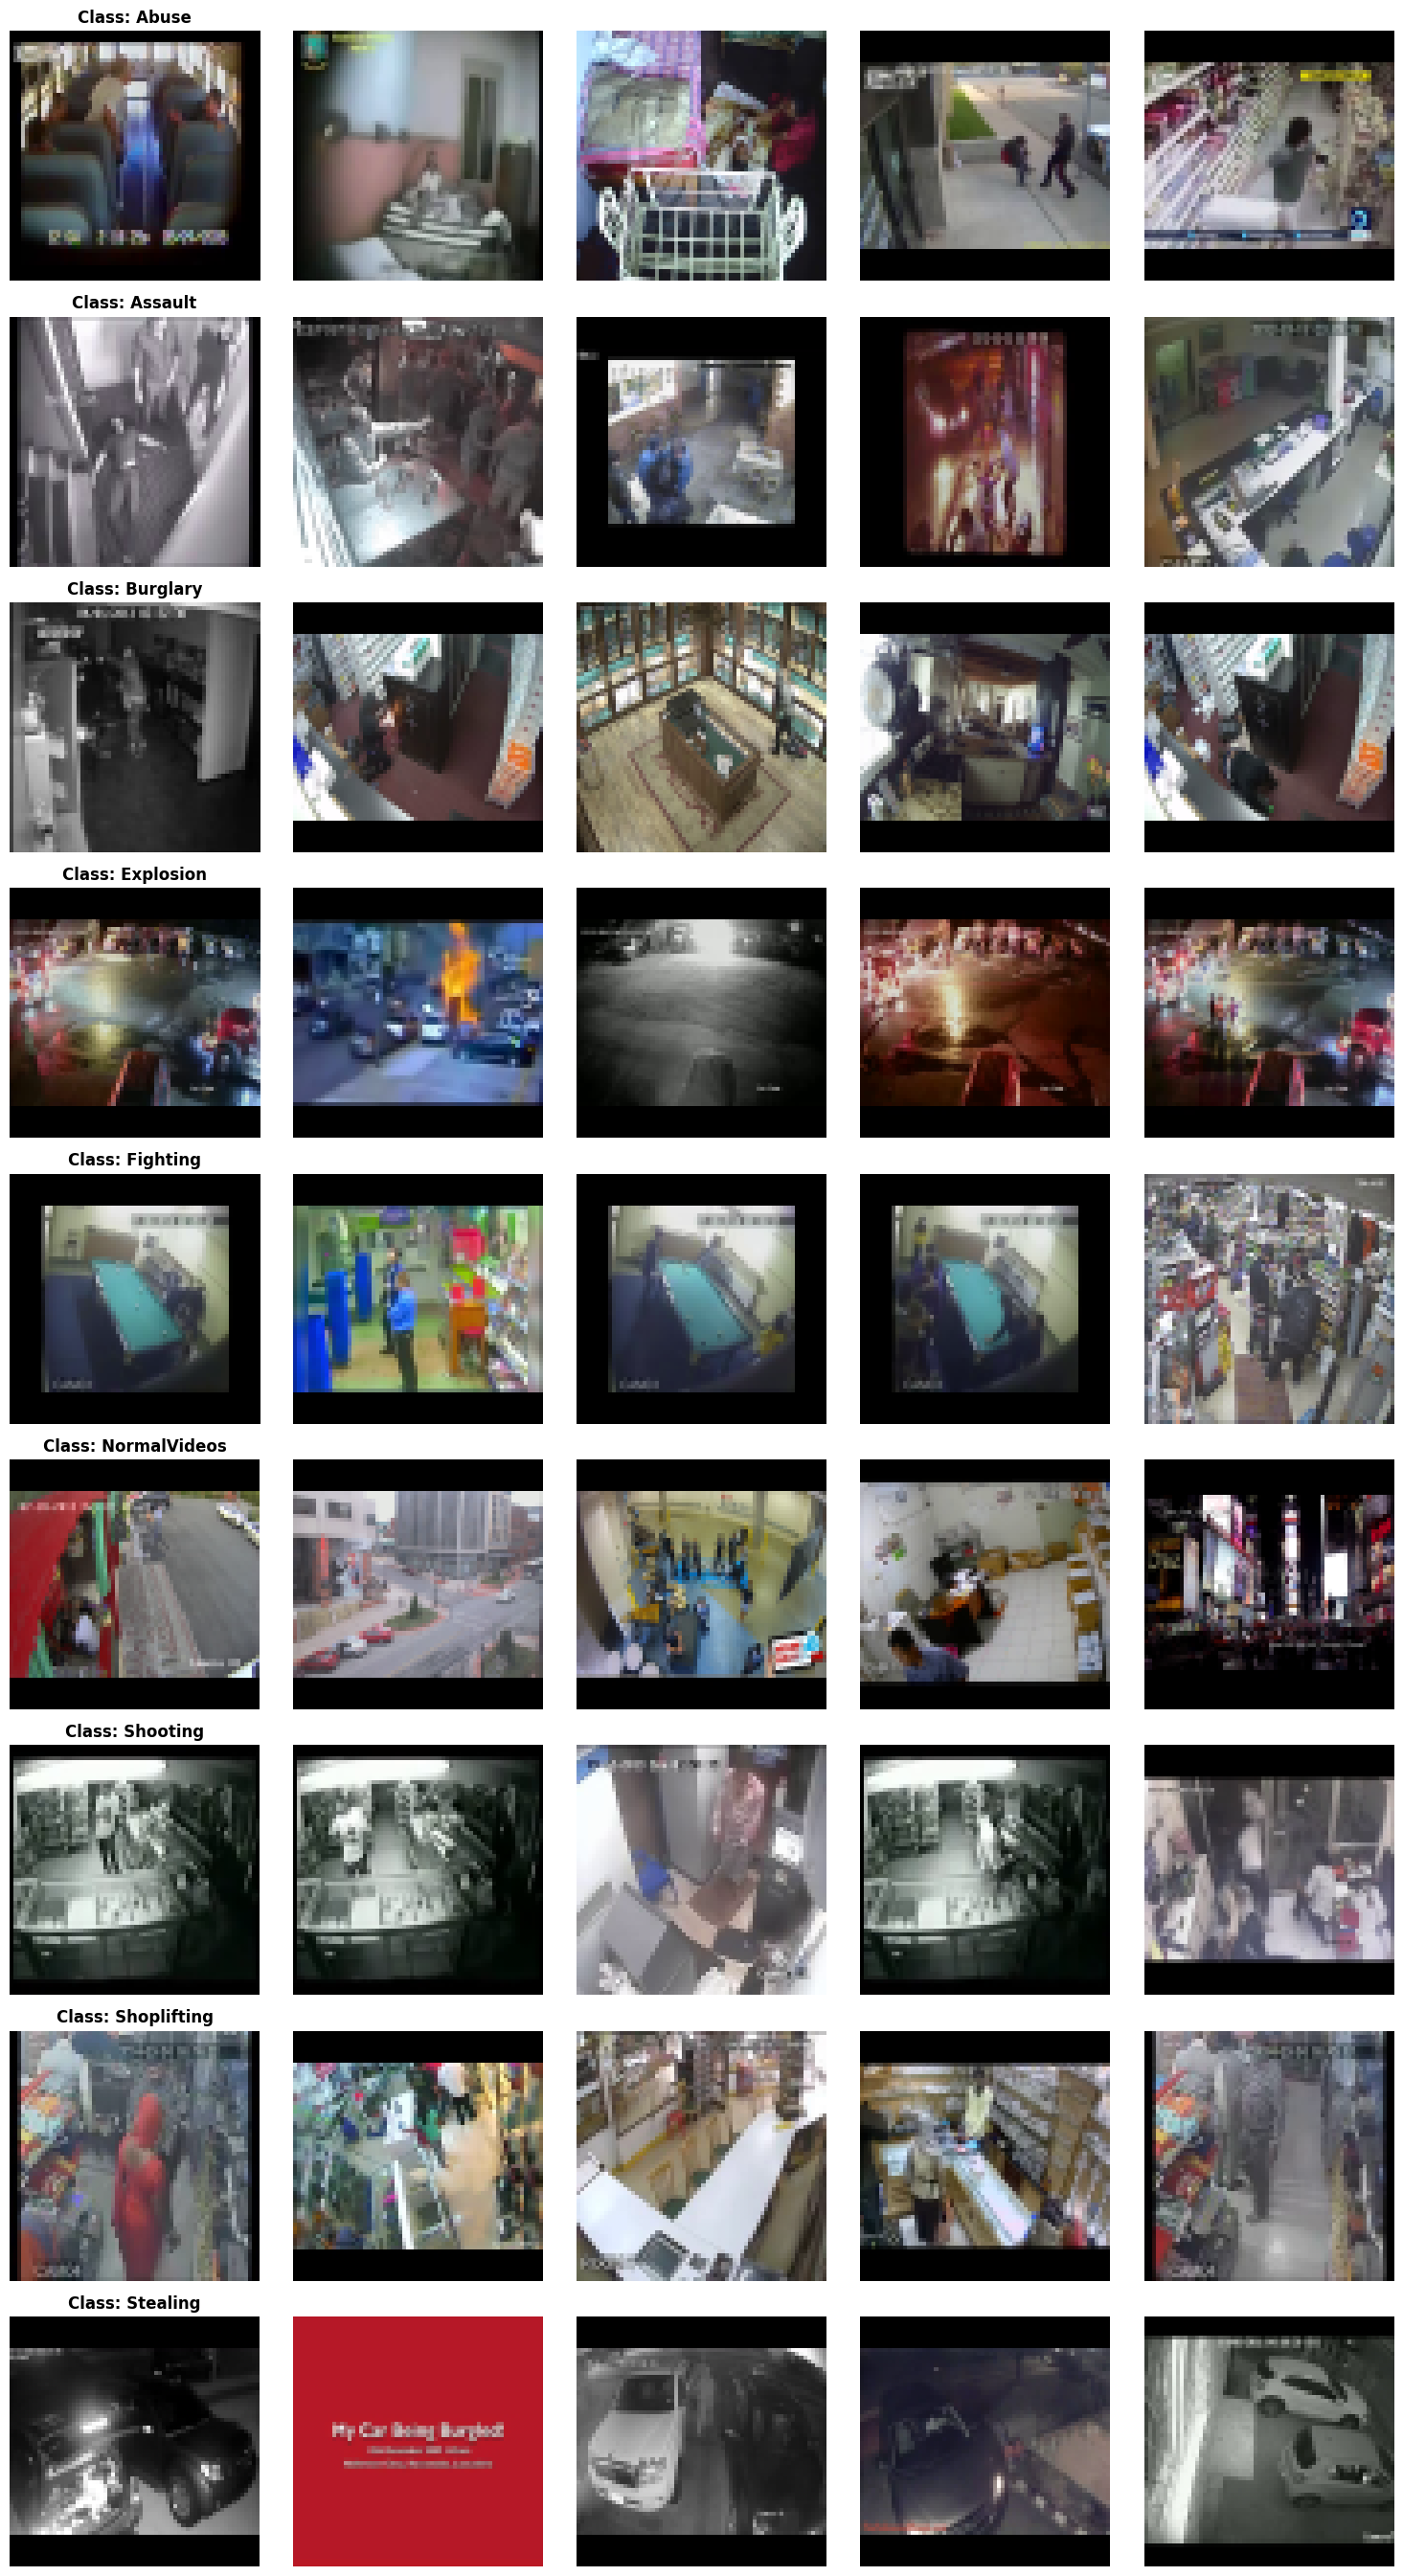

Displayed 5 sample images for each of the 9 classes


In [14]:
unique_classes = sorted(train_balanced['labels'].unique())
fig, axes = plt.subplots(len(unique_classes), 5, figsize=(15, 3 * len(unique_classes)))
axes = axes.flatten()

for idx, class_label in enumerate(unique_classes):
    class_images = train_balanced[train_balanced['labels'] == class_label].iloc[:5]
    for i, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['image']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx * 5 + i].imshow(img)
        axes[idx * 5 + i].axis('off')
        if i == 0:
            axes[idx * 5].set_title(f'Class: {class_label}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Displayed 5 sample images for each of the {len(unique_classes)} classes")

In [15]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale', target_size=(48, 48))
        img_array = img_to_array(img)
        features.append(img_array)
    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)
    return features

print("Extracting features from training images...")
print("Converting RGB to Grayscale and resizing from 64x64 to 48x48...\n")
train_features = extract_features(train_balanced['image'])

print(f"\nTrain Features Shape: {train_features.shape}")
print(f"Data Type: {train_features.dtype}")
print(f"Min Value: {train_features.min():.2f}, Max Value: {train_features.max():.2f}")

Extracting features from training images...
Converting RGB to Grayscale and resizing from 64x64 to 48x48...



100%|██████████| 87140/87140 [14:42<00:00, 98.79it/s] 



Train Features Shape: (87140, 48, 48, 1)
Data Type: float32
Min Value: 0.00, Max Value: 255.00


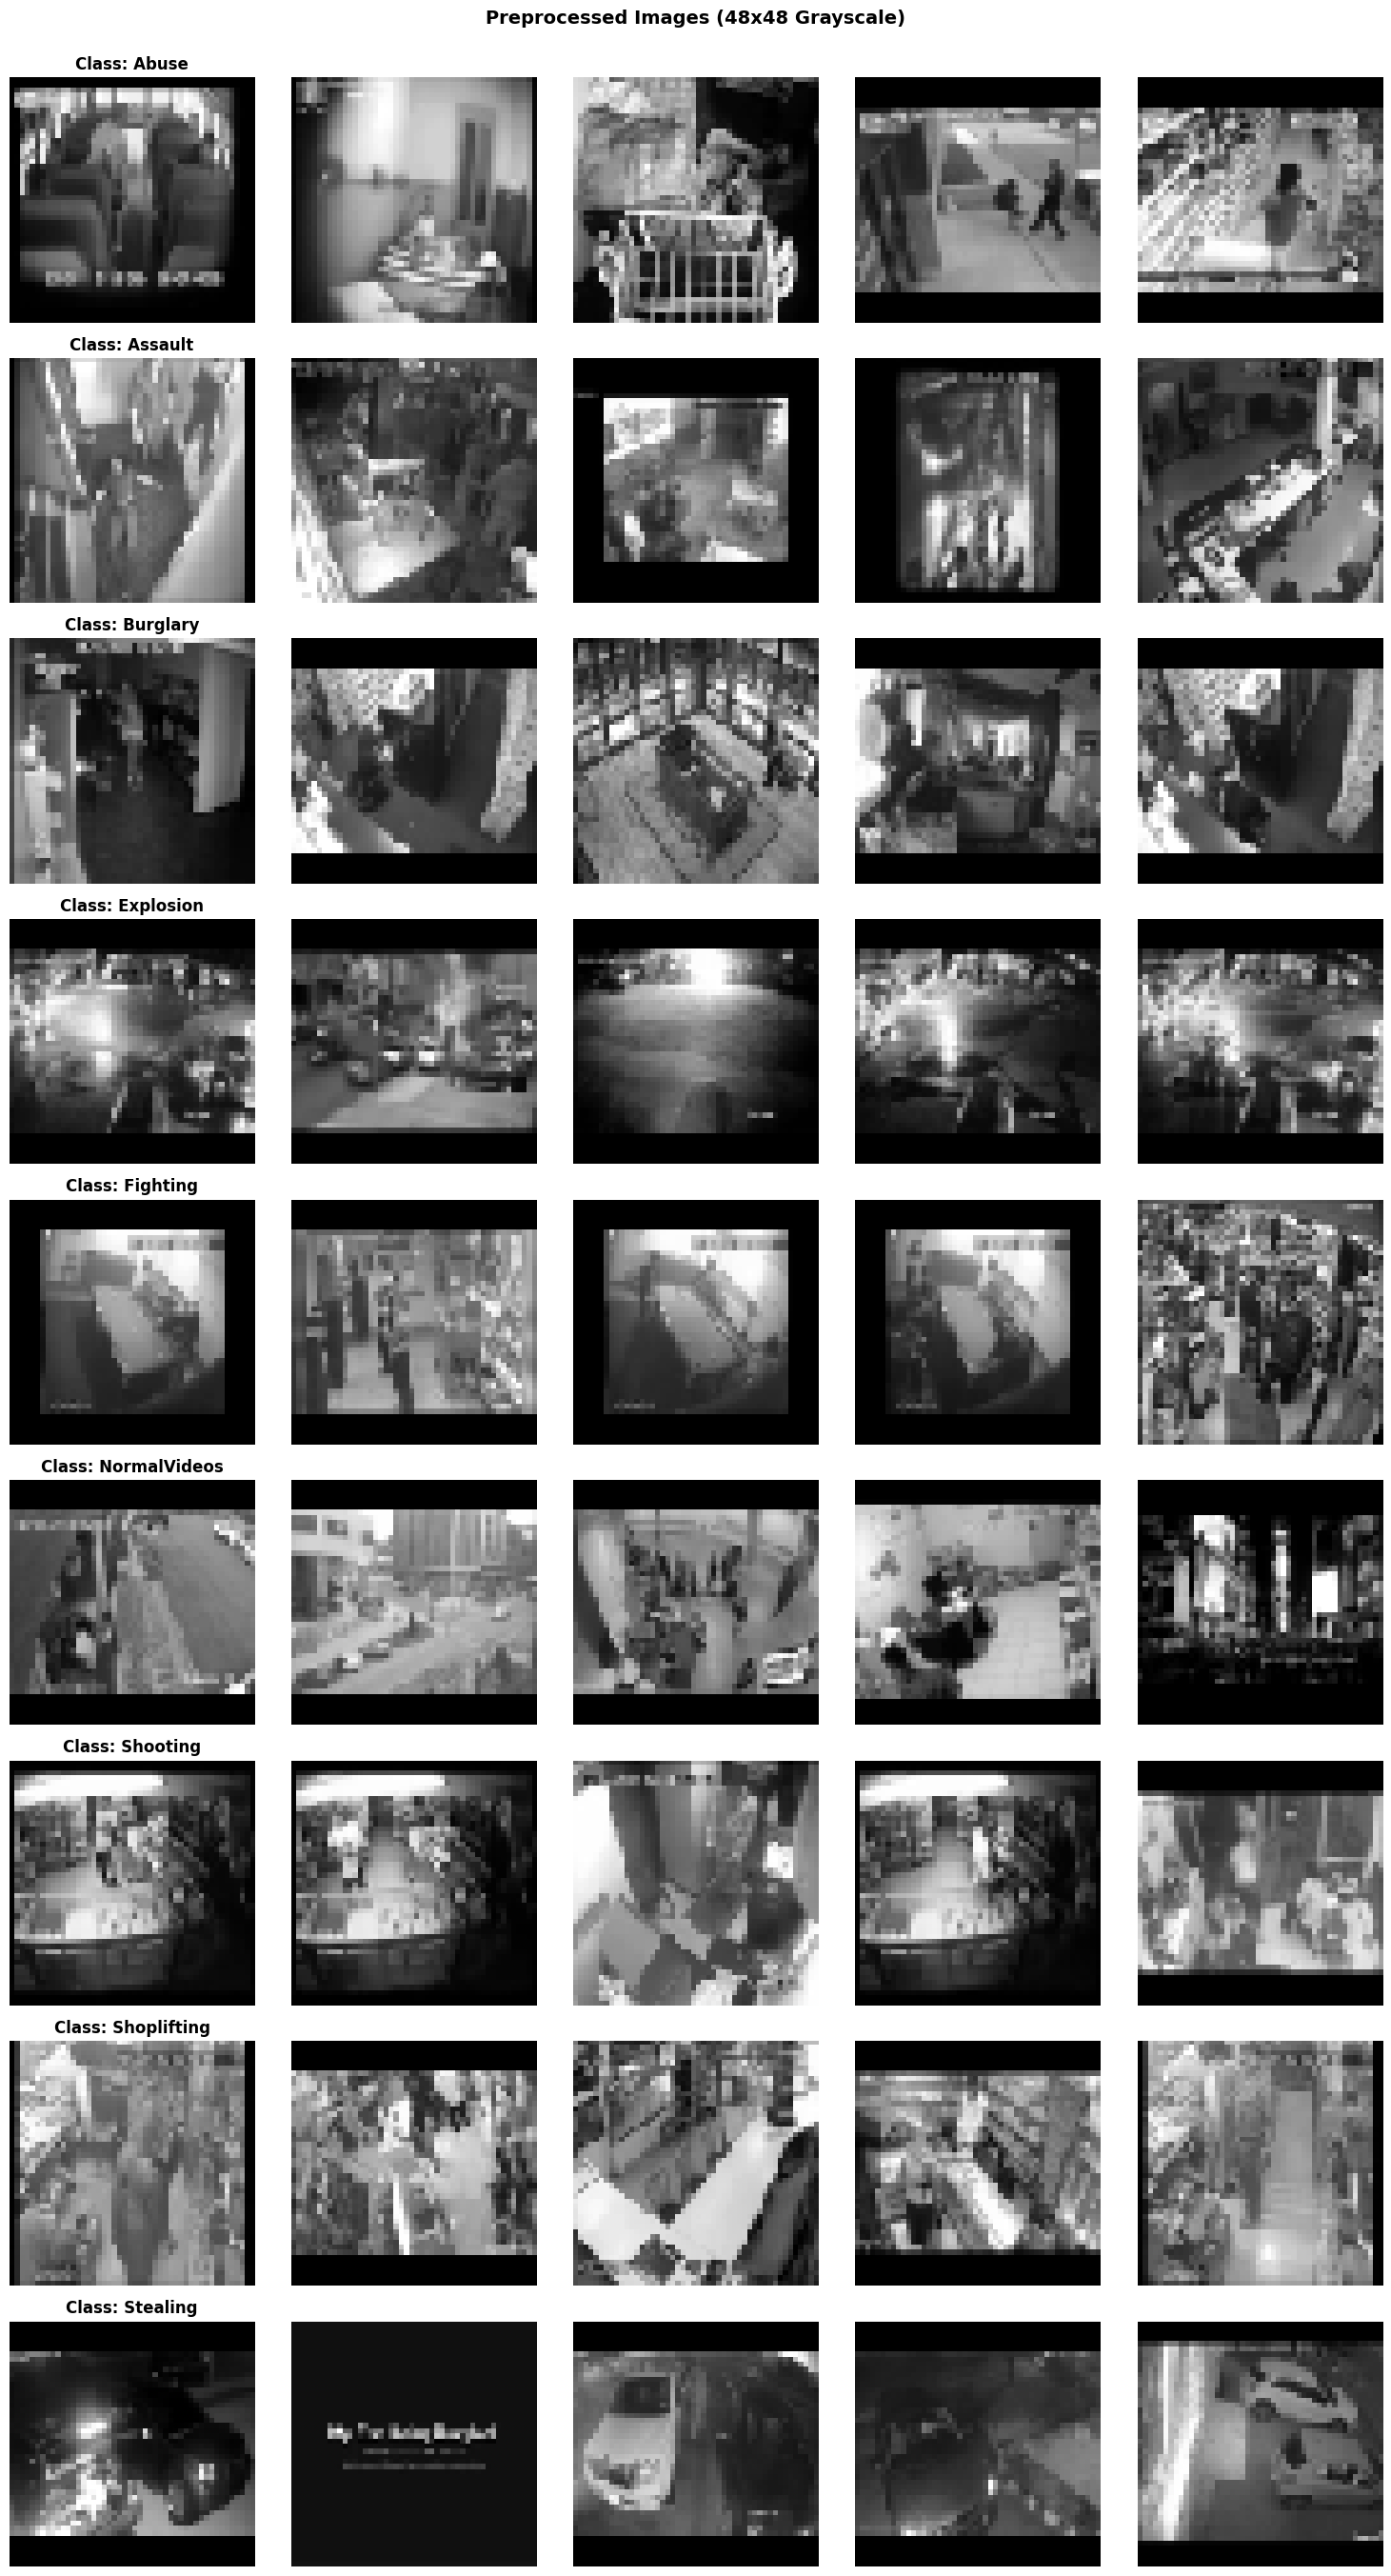

Displayed preprocessed grayscale images for all 9 classes


In [16]:
unique_classes = sorted(train_balanced['labels'].unique())
fig, axes = plt.subplots(len(unique_classes), 5, figsize=(15, 3 * len(unique_classes)))
axes = axes.flatten()

for idx, class_label in enumerate(unique_classes):
    class_indices = train_balanced[train_balanced['labels'] == class_label].index[:5]
    for i, img_idx in enumerate(class_indices):
        img = train_features[img_idx]
        axes[idx * 5 + i].imshow(img.reshape(48, 48), cmap='gray')
        axes[idx * 5 + i].axis('off')
        if i == 0:
            axes[idx * 5].set_title(f'Class: {class_label}', fontsize=12, fontweight='bold')

plt.suptitle('Preprocessed Images (48x48 Grayscale)', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"Displayed preprocessed grayscale images for all {len(unique_classes)} classes")

In [17]:
print("Extracting features from test images...")
print("Converting RGB to Grayscale and resizing from 64x64 to 48x48...\n")
test_features = extract_features(test['image'])

print(f"\nTest Features Shape: {test_features.shape}")
print(f"Data Type: {test_features.dtype}") 
print(f"Min Value: {test_features.min():.2f}, Max Value: {test_features.max():.2f}")

Extracting features from test images...
Converting RGB to Grayscale and resizing from 64x64 to 48x48...



100%|██████████| 100541/100541 [15:29<00:00, 108.14it/s]



Test Features Shape: (100541, 48, 48, 1)
Data Type: float32
Min Value: 0.00, Max Value: 255.00


In [18]:
features = train_features / 255.0
test_features_normalized = test_features / 255.0

print("Training Features:")
print(f"Shape: {features.shape}")
print(f"Min Value: {features.min():.4f}, Max Value: {features.max():.4f}")
print(f"Mean: {features.mean():.4f}, Std: {features.std():.4f}")

print("\nTest Features:")
print(f"Shape: {test_features_normalized.shape}")
print(f"Min Value: {test_features_normalized.min():.4f}, Max Value: {test_features_normalized.max():.4f}")
print(f"Mean: {test_features_normalized.mean():.4f}, Std: {test_features_normalized.std():.4f}")

Training Features:
Shape: (87140, 48, 48, 1)
Min Value: 0.0000, Max Value: 1.0000
Mean: 0.3502, Std: 0.2608

Test Features:
Shape: (100541, 48, 48, 1)
Min Value: 0.0000, Max Value: 1.0000
Mean: 0.3515, Std: 0.2520


In [19]:
labels = train_balanced['labels']

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print("Label Encoding Mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

print(f"\nOriginal Labels Shape: {labels.shape}")
print(f"Encoded Labels Shape: {labels_encoded.shape}")
print(f"Number of Classes: {len(le.classes_)}")
print(f"\nEncoded Labels Range: {labels_encoded.min()} to {labels_encoded.max()}")

Label Encoding Mapping:
0: Abuse
1: Assault
2: Burglary
3: Explosion
4: Fighting
5: NormalVideos
6: Shooting
7: Shoplifting
8: Stealing

Original Labels Shape: (87140,)
Encoded Labels Shape: (87140,)
Number of Classes: 9

Encoded Labels Range: 0 to 8


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)

print("Dataset Split (80% Train, 20% Validation):")
print(f"\nTraining Set:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print(f"\nValidation Set:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass Distribution in Training Set:")
unique, counts = np.unique(y_train, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"{le.classes_[label_idx]}: {count}")

print("\nClass Distribution in Validation Set:")
unique, counts = np.unique(y_test, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"{le.classes_[label_idx]}: {count}")

Dataset Split (80% Train, 20% Validation):

Training Set:
X_train shape: (69712, 48, 48, 1)
y_train shape: (69712,)

Validation Set:
X_test shape: (17428, 48, 48, 1)
y_test shape: (17428,)

Class Distribution in Training Set:
Abuse: 8000
Assault: 8000
Burglary: 8000
Explosion: 8000
Fighting: 8000
NormalVideos: 8000
Shooting: 5712
Shoplifting: 8000
Stealing: 8000

Class Distribution in Validation Set:
Abuse: 2000
Assault: 2000
Burglary: 2000
Explosion: 2000
Fighting: 2000
NormalVideos: 2000
Shooting: 1428
Shoplifting: 2000
Stealing: 2000


In [22]:
model = Sequential()

model.add(Input(shape=(48, 48, 1)))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(9, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 46, 46, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,232,713 (16.15 MB)

 Trainable params: 4,232,713 (16.15 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"\nTotal Parameters: {model.count_params():,}")

Model compiled successfully!

Total Parameters: 4,232,713


In [24]:
print("Starting model training...\n")

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nTraining completed!")

Starting model training...

Epoch 1/5
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 1548s 709ms/step - accuracy: 0.4306 - loss: 1.5433 - val_accuracy: 0.9244 - val_loss: 0.2486
Epoch 2/5
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 1560s 716ms/step - accuracy: 0.8829 - loss: 0.3772 - val_accuracy: 0.9612 - val_loss: 0.1184
Epoch 3/5
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 1566s 708ms/step - accuracy: 0.9192 - loss: 0.2603 - val_accuracy: 0.9720 - val_loss: 0.0943
Epoch 4/5
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 1526s 701ms/step - accuracy: 0.9385 - loss: 0.2070 - val_accuracy: 0.9755 - val_loss: 0.0846
Epoch 5/5
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 1533s 704ms/step - accuracy: 0.9433 - loss: 0.1926 - val_accuracy: 0.9785 - val_loss: 0.0736

Training completed!


In [25]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\nValidation Results:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

545/545 ━━━━━━━━━━━━━━━━━━━━ 74s 135ms/step - accuracy: 0.9794 - loss: 0.0722

Validation Results:
Loss: 0.0736
Accuracy: 0.9785 (97.85%)


In [26]:
print("Generating predictions on validation set...\n")
y_pred = model.predict(X_test, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

report = classification_report(y_test, y_pred_classes, target_names=le.classes_, digits=4)
print("\nClassification Report:")
print(report)

Generating predictions on validation set...

545/545 ━━━━━━━━━━━━━━━━━━━━ 73s 133ms/step

Classification Report:
              precision    recall  f1-score   support

       Abuse     0.9735    0.9740    0.9738      2000
     Assault     0.9805    0.9820    0.9813      2000
    Burglary     0.9909    0.9815    0.9862      2000
   Explosion     0.9959    0.9745    0.9851      2000
    Fighting     0.9912    0.9625    0.9767      2000
NormalVideos     0.9218    0.9605    0.9407      2000
    Shooting     0.9923    0.9881    0.9902      1428
 Shoplifting     0.9990    0.9930    0.9960      2000
    Stealing     0.9693    0.9935    0.9812      2000

    accuracy                         0.9785     17428
   macro avg     0.9794    0.9788    0.9790     17428
weighted avg     0.9790    0.9785    0.9786     17428



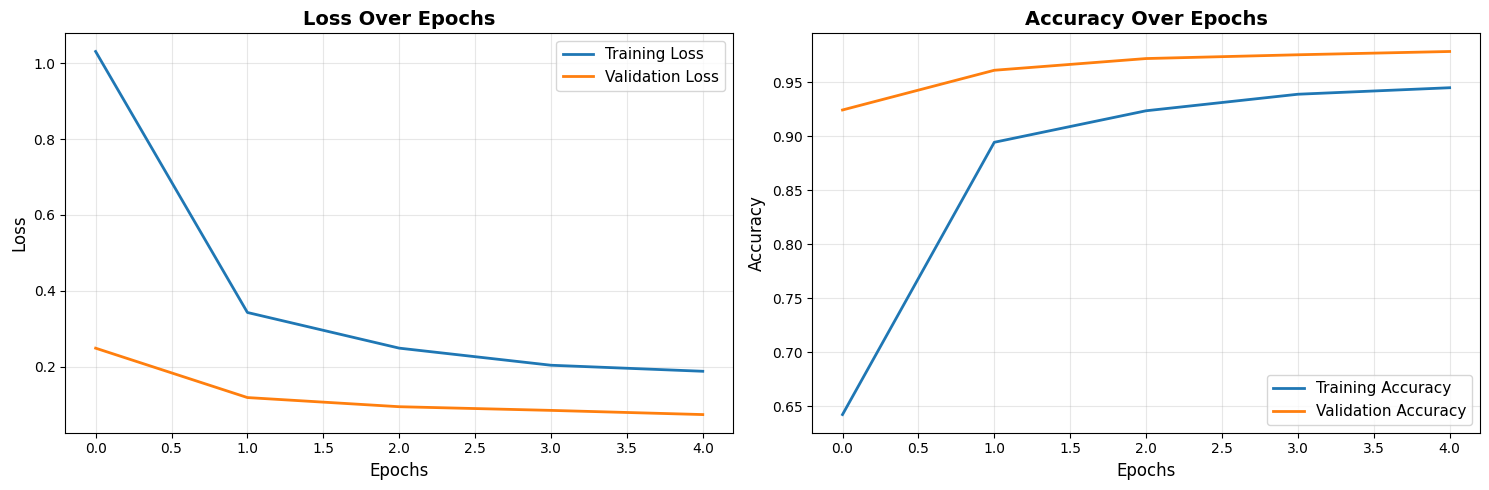

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

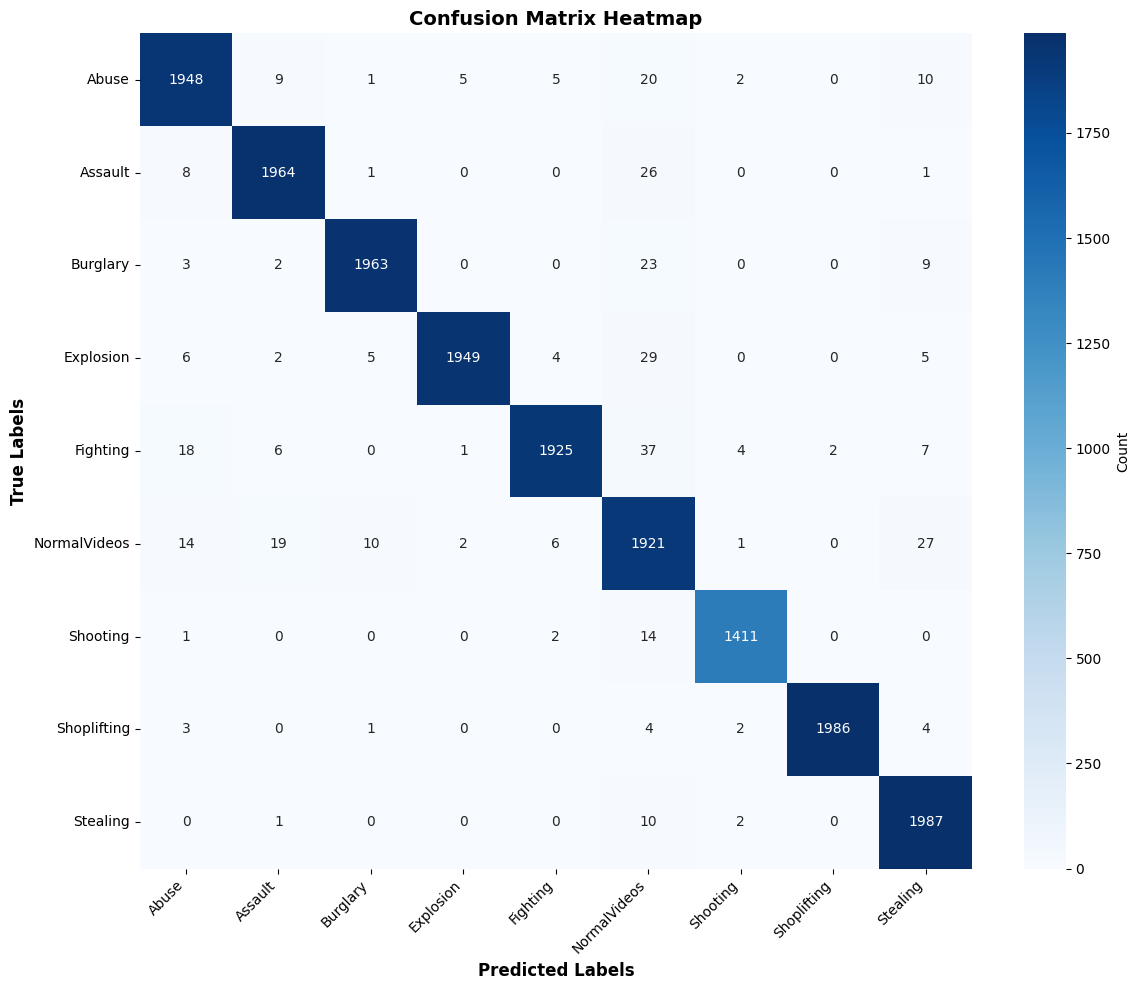


Confusion Matrix Analysis:
Total Correct Predictions: 17054
Total Predictions: 17428
Overall Accuracy: 97.85%


In [28]:
conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Labels", fontsize=12, fontweight='bold')
plt.ylabel("True Labels", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Analysis:")
print(f"Total Correct Predictions: {np.trace(conf_matrix)}")
print(f"Total Predictions: {np.sum(conf_matrix)}")
print(f"Overall Accuracy: {np.trace(conf_matrix) / np.sum(conf_matrix) * 100:.2f}%")

In [33]:
model_save_path = '/kaggle/working/anomaly_detection_model.h5'
model.save(model_save_path)

print(f"Model saved successfully at: {model_save_path}")
print(f"Model size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

import pickle
label_encoder_path = '/kaggle/working/label_encoder.pkl'
with open(label_encoder_path, 'wb') as f:
    pickle.dump(le, f)

print(f"\nLabel encoder saved at: {label_encoder_path}")
print(f"\nClass mapping saved:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

Model saved successfully at: /kaggle/working/anomaly_detection_model.h5
Model size: 48.51 MB

Label encoder saved at: /kaggle/working/label_encoder.pkl

Class mapping saved:
0: Abuse
1: Assault
2: Burglary
3: Explosion
4: Fighting
5: NormalVideos
6: Shooting
7: Shoplifting
8: Stealing


In [36]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Input

# Build Multi-Layer Perceptron
mlp_model = Sequential()

mlp_model.add(Input(shape=(48, 48, 1)))
mlp_model.add(Flatten())

mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(Dropout(0.4))

mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dropout(0.3))

mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dropout(0.3))

mlp_model.add(Dense(9, activation='softmax'))

mlp_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,545 (5.13 MB)

 Trainable params: 1,345,545 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training MLP Model...\n")

history_mlp = mlp_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nTraining completed!")

Training MLP Model...

Epoch 1/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.7577 - loss: 0.7125 - val_accuracy: 0.8495 - val_loss: 0.5173
Epoch 2/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7792 - loss: 0.6615 - val_accuracy: 0.8681 - val_loss: 0.4998
Epoch 3/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7444 - loss: 0.7638 - val_accuracy: 0.8414 - val_loss: 0.5382
Epoch 4/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7187 - loss: 0.8402 - val_accuracy: 0.8575 - val_loss: 0.4990
Epoch 5/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7551 - loss: 0.7540 - val_accuracy: 0.8396 - val_loss: 0.5451
Epoch 6/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7462 - loss: 0.7753 - val_accuracy: 0.7909 - val_loss: 0.6602
Epoch 7/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.7603 - loss: 0.7365 - val_accuracy: 0.8233 - val_loss: 0.5686
Epoch 8/50
2179/2179 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/st

In [40]:
# Evaluate
loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test, y_test, verbose=1)
print(f"\nMLP Validation Results:")
print(f"Loss: {loss_mlp:.4f}")
print(f"Accuracy: {accuracy_mlp:.4f} ({accuracy_mlp*100:.2f}%)")

# Predictions and Classification Report
y_pred_mlp = mlp_model.predict(X_test, verbose=1)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

report_mlp = classification_report(y_test, y_pred_mlp_classes, target_names=le.classes_)
print("\nClassification Report:")
print(report_mlp)

545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8119 - loss: 0.6289

MLP Validation Results:
Loss: 0.6339
Accuracy: 0.8092 (80.92%)
545/545 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report:
              precision    recall  f1-score   support

       Abuse       0.97      0.82      0.89      2000
     Assault       0.87      0.84      0.85      2000
    Burglary       0.80      0.84      0.82      2000
   Explosion       0.99      0.84      0.91      2000
    Fighting       0.85      0.90      0.87      2000
NormalVideos       0.69      0.84      0.76      2000
    Shooting       0.87      0.85      0.86      1428
 Shoplifting       0.95      0.49      0.65      2000
    Stealing       0.58      0.88      0.70      2000

    accuracy                           0.81     17428
   macro avg       0.84      0.81      0.81     17428
weighted avg       0.84      0.81      0.81     17428



In [44]:
# Store MLP results for comparison
mlp_accuracy = 0.8092
mlp_loss = 0.6339

# Store CNN results (from your previous training)
cnn_accuracy = 0.9785
cnn_loss = 0.0736

print("Results Summary:")
print("="*50)
print(f"\nCNN Model:")
print(f"  Accuracy: {cnn_accuracy:.4f} ({cnn_accuracy*100:.2f}%)")
print(f"  Loss: {cnn_loss:.4f}")

print(f"\nMLP Model:")
print(f"  Accuracy: {mlp_accuracy:.4f} ({mlp_accuracy*100:.2f}%)")
print(f"  Loss: {mlp_loss:.4f}")

print(f"\nImprovement:")
print(f"  Accuracy Difference: {(cnn_accuracy - mlp_accuracy)*100:.2f}%")
print(f"  CNN is {((cnn_accuracy/mlp_accuracy - 1)*100):.2f}% better")

Results Summary:

CNN Model:
  Accuracy: 0.9785 (97.85%)
  Loss: 0.0736

MLP Model:
  Accuracy: 0.8092 (80.92%)
  Loss: 0.6339

Improvement:
  Accuracy Difference: 16.93%
  CNN is 20.92% better


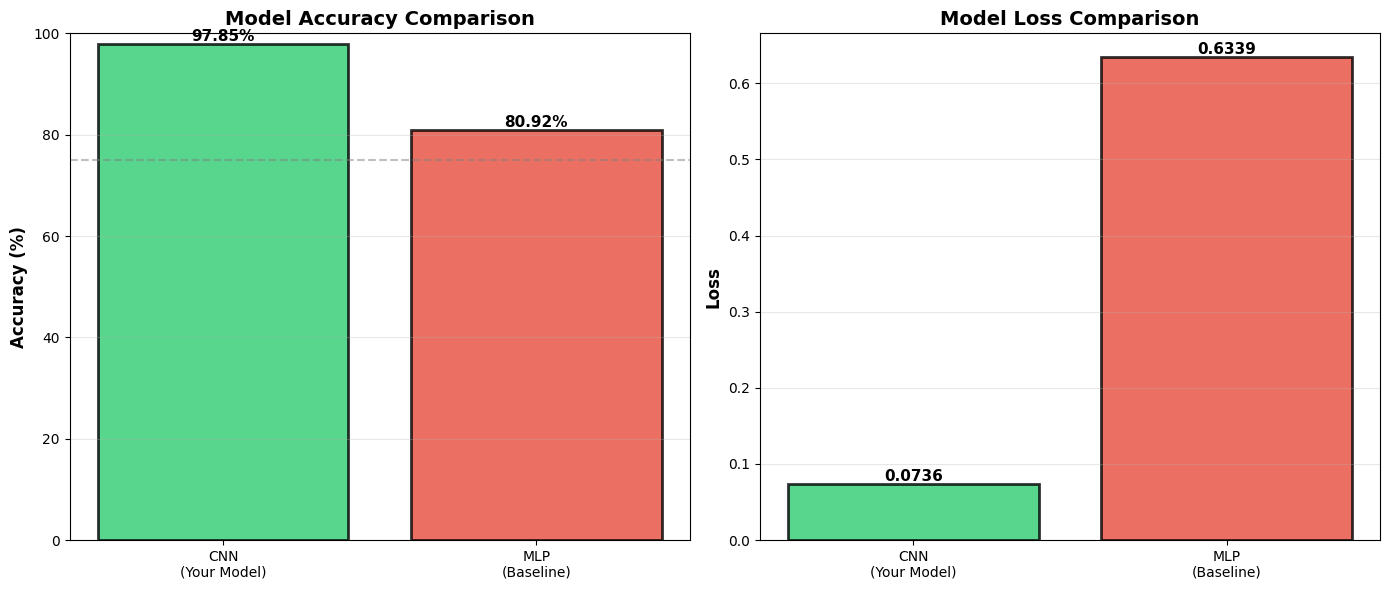

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Create comparison data
models = ['CNN\n(Your Model)', 'MLP\n(Baseline)']
accuracies = [cnn_accuracy * 100, mlp_accuracy * 100]
losses = [cnn_loss, mlp_loss]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
bars1 = axes[0].bar(models, accuracies, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=75, color='gray', linestyle='--', alpha=0.5, label='75% threshold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Loss comparison
bars2 = axes[1].bar(models, losses, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [47]:
# Save MLP model
mlp_model_save_path = '/kaggle/working/mlp_model.h5'
mlp_model.save(mlp_model_save_path)
print(f"MLP Model saved successfully at: {mlp_model_save_path}")
print(f"Model size: {os.path.getsize(mlp_model_save_path) / (1024*1024):.2f} MB")

MLP Model saved successfully at: /kaggle/working/mlp_model.h5
Model size: 15.44 MB


In [48]:
!zip -r model2.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 77%)
  adding: kaggle/working/anomaly_detection_model.h5 (deflated 6%)
  adding: kaggle/working/label_encoder.pkl (deflated 21%)
  adding: kaggle/working/mlp_model.h5 (deflated 39%)


In [50]:
from IPython.display import FileLink
FileLink(r'model2.zip')

/kaggle/working/model2.zip